# Study of optimal design of a truss

In [2]:
import numpy as np
import libTruss
import libTruss_dev as libdev

## Set the geometry (mesh)

In [3]:
l = 1.0
# mesh
Nodes = np.array([[0, 0], [l, 0], [l, l]])
Connectivity = np.array([[0, 1], [1, 2]])


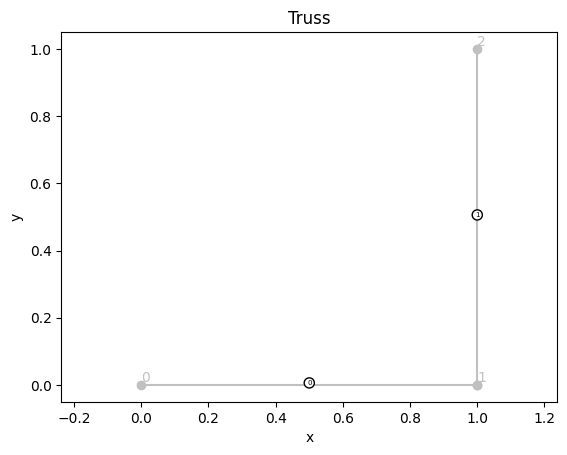

In [4]:
# Visualization
libTruss.plotResults(Nodes, Connectivity, title='Truss',
                     options={'showNumPoints': True, 'showNumElem': True})

## Set Material properties

In [5]:
class material:
    def __init__(self):
        self.E = 200e9      # Young's Modulus in Pa (Steel)
        self.rho = 7800.0   # Density in kg/m3
        self.sigma_y = 250e6
mat = material()
print('Young modulus:', mat.E)

# Define Section Area
Areas = [1e-4, 1e-4]

Young modulus: 200000000000.0


## Building of the elementary stiffness matrix

In [6]:
stiff_elem = libdev.getElemBarStiffnessMatrix(Nodes[0], Nodes[1], mat.E, Areas[0])
print("Elementary Matrix (Sample):\n", stiff_elem)

Elementary Matrix (Sample):
 [[ 20000000.         0. -20000000.        -0.]
 [        0.         0.        -0.        -0.]
 [-20000000.        -0.  20000000.         0.]
 [       -0.        -0.         0.         0.]]


## Assembly of the global stiffness matrix

In [7]:
stiff_global = libdev.getGlobalStiffnessMatrix(Nodes, Connectivity, mat.E, Areas)

## Finite Elements problem computation

Nodal Displacements: [ 0.          0.          0.00025981 -0.00015     0.          0.        ]


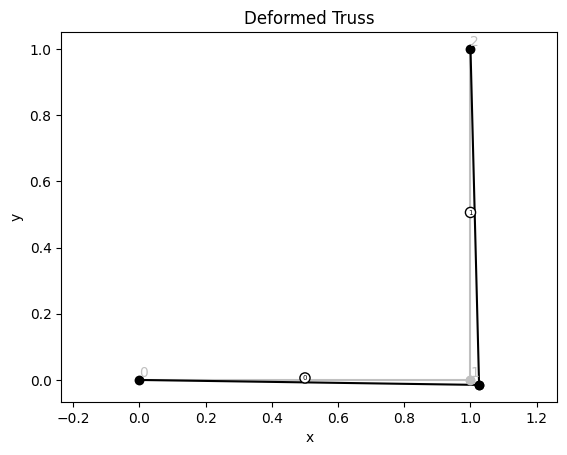

In [8]:
loads = [{'node': 1, 'value': [6000*np.cos(np.radians(30)), -6000*np.sin(np.radians(30))]}] # -6kN in y-direction -30 degrees
bc_indices = np.array([0, 1, 4, 5])
f_vec = libdev.getGlobalForceVector(Nodes.shape[0], loads)
solFE = libdev.solveFEProblem(stiff_global, f_vec, bc_indices)
print("Nodal Displacements:", solFE)

libTruss.plotResults(Nodes, Connectivity, Ufull=solFE, title='Deformed Truss', 
                     options={'showNumPoints': True, 'showNumElem': True}, scaleFactor=100)

## Computation of stresses and strains in bars

In [9]:
stress_elem, strain_elem = libdev.getElemStressStrain(Nodes[0], Nodes[1], 
                                                      solFE[0:2], solFE[2:4], 
                                                      mat.E, l)

In [10]:
stress_strain = libdev.getStressStrain(Nodes, Connectivity, solFE, mat.E)
print("Stresses in bars:", stress_strain[0])

Stresses in bars: [51961524.22706632 30000000.        ]


## Parametric analysis

In [11]:
mass_truss = libdev.getMassTruss(Nodes, Connectivity, Areas, mat.rho)
print(f"Total Mass: {mass_truss} kg")

Total Mass: 1.56 kg


In [12]:
valuesFE = libdev.parametricFE(Nodes, Connectivity, Areas, loads, bc_indices, mat.E, mat.rho)
print("Parametric Analysis Result (Mass):", valuesFE[0])

Parametric Analysis Result (Mass): 1.56


## Parametric gradients computations

In [13]:
grad_stiff = libdev.getGlobalStiffnessMatrixDerivative(Nodes, Connectivity, mat.E, Areas)

In [14]:
#grad_sol = libdev.solveFEProblemGrad(...) # Placeholder for bonus section

## Optimization

In [15]:
from scipy.optimize import minimize
import numpy as np

# --- 1. SETUP PARAMETERS ---
SIGMA_YIELD = 250e6
MIN_AREA = 1e-6
SCALE_FACTOR = 1e4  # Scale variables to be ~1.0 for the optimizer

# --- 2. DEFINE OBJECTIVE & CONSTRAINTS ---
def objective_function(x_scaled):
    x_phys = x_scaled / SCALE_FACTOR
    mass, _, _ = libdev.parametricFE(Nodes, Connectivity, x_phys, 
                                     loads, bc_indices, mat.E, mat.rho)
    return mass

def constraint_stress_normalized(x_scaled):
    x_phys = x_scaled / SCALE_FACTOR
    if np.any(x_phys <= 0): return -1.0 # Safety
    
    _, stresses, _ = libdev.parametricFE(Nodes, Connectivity, x_phys, 
                                         loads, bc_indices, mat.E, mat.rho)
    
    # CORRECT LOGIC: Returns positive value if Safe (Yield > Stress)
    # Using minimum margin: min((Yield - Stress) / Yield)
    return np.min((SIGMA_YIELD - np.abs(stresses)) / SIGMA_YIELD)

def constraint_area_positive(x_scaled):
    x_phys = x_scaled / SCALE_FACTOR
    # Returns positive if Area > Min
    return np.min((x_phys - MIN_AREA) / 1e-4)

# --- 3. RUN OPTIMIZATION ---
print("--- Starting Optimization ---")
# Initial guess: 10 cm^2 (0.001 m^2) -> Scaled to 100.0
x0_scaled = np.array([100.0, 100.0]) 

constraints = [
    {'type': 'ineq', 'fun': constraint_stress_normalized},
    {'type': 'ineq', 'fun': constraint_area_positive}
]

result = minimize(objective_function, x0_scaled, method='COBYLA', 
                  constraints=constraints, 
                  options={'disp': True, 'maxiter': 5000, 'rhobeg': 1.0})

# --- 4. SHOW RESULTS WITH STRESS ---
opt_areas = result.x / SCALE_FACTOR
opt_mass = result.fun

print("\n" + "="*30)
print("       FINAL RESULTS")
print("="*30)
print(f"Optimal Mass:   {opt_mass:.5f} kg")
print(f"Optimal Areas:  [{opt_areas[0]:.3e}, {opt_areas[1]:.3e}] m^2")

# Calculate Stresses for the Optimal Solution
_, opt_stresses, _ = libdev.parametricFE(Nodes, Connectivity, opt_areas, 
                                         loads, bc_indices, mat.E, mat.rho)

print("-" * 30)
print("STRESS CHECK:")
print(f"Bar 1 Stress:   {opt_stresses[0]:.2e} Pa  (Yield: {SIGMA_YIELD:.2e} Pa)")
print(f"Bar 2 Stress:   {opt_stresses[1]:.2e} Pa  (Yield: {SIGMA_YIELD:.2e} Pa)")
print("-" * 30)

# Verify safety factor
safety_margins = (SIGMA_YIELD - np.abs(opt_stresses)) / SIGMA_YIELD
if np.all(safety_margins >= -1e-3): # Allow tiny numerical tolerance
    print(">>> DESIGN IS SAFE")
else:
    print(">>> DESIGN IS UNSAFE (Check constraints)")

--- Starting Optimization ---
Return from COBYLA because the trust region radius reaches its lower bound.
Number of function values = 83   Least value of F = 0.2557969297343439   Constraint violation = 0.0
The corresponding X is: [0.20788409 0.12006069]
The constraint value is: [-0.00018278 -0.11006069]


       FINAL RESULTS
Optimal Mass:   0.25580 kg
Optimal Areas:  [2.079e-05, 1.201e-05] m^2
------------------------------
STRESS CHECK:
Bar 1 Stress:   2.50e+08 Pa  (Yield: 2.50e+08 Pa)
Bar 2 Stress:   2.50e+08 Pa  (Yield: 2.50e+08 Pa)
------------------------------
>>> DESIGN IS SAFE


## The plot

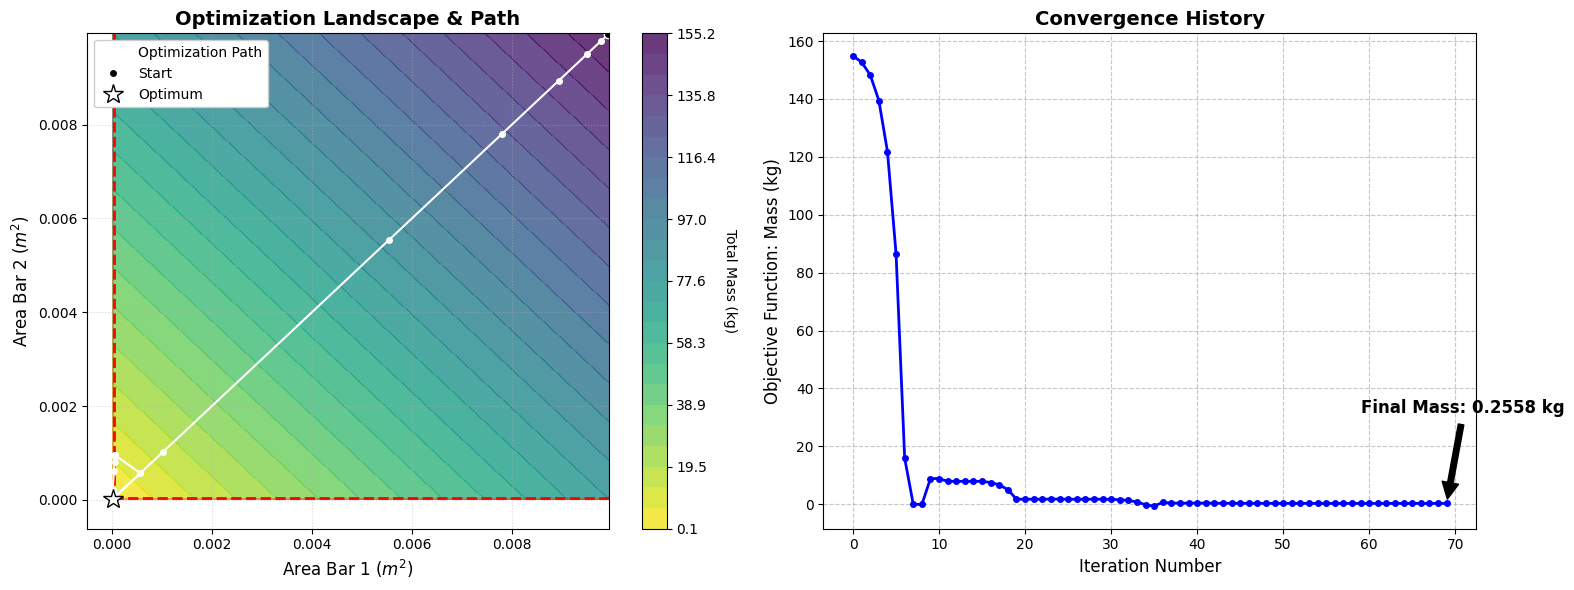

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# --- 1. PREPARE DATA & ANALYTICAL MODEL FOR PLOTTING ---
def get_analytical_constraints(a1, a2):
    force_1 = 6000 * np.cos(np.radians(30))
    force_2 = 6000 * np.sin(np.radians(30))
    
    sigma_y = 250e6
    
    # Positive if violated (Stress > Yield)
    c1 = (force_1 / a1) - sigma_y 
    c2 = (force_2 / a2) - sigma_y
    return c1, c2

def get_mass_analytical(a1, a2, rho=7800, L=1.0):
    vol = (a1 * L) + (a2 * L)
    return vol * rho

# --- 2. RE-RUN OPTIMIZATION WITH HISTORY TRACKING ---
history = {'x': [], 'fun': []}

def callback_recorder(xk):
    # Note: COBYLA works with scaled variables, so we unscale for storage
    x_phys = xk / SCALE_FACTOR
    # Ensure objective_function is available in your scope
    mass = objective_function(xk) 
    history['x'].append(x_phys)
    history['fun'].append(mass)

# Re-run minimize
x0_scaled = np.array([100.0, 100.0]) # Initial guess
res = minimize(objective_function, x0_scaled, method='COBYLA', 
               constraints=constraints, callback=callback_recorder,
               options={'maxiter': 5000})

# Add the final point to history if not present
if not np.array_equal(history['x'][-1], res.x / SCALE_FACTOR):
    history['x'].append(res.x / SCALE_FACTOR)
    history['fun'].append(res.fun)

x_hist = np.array(history['x'])
fun_hist = np.array(history['fun'])

# --- 3. GENERATE PLOTS (SIDE-BY-SIDE) ---
# Change figsize to be wider (e.g., width 16, height 6)
fig = plt.figure(figsize=(16, 6))

# === LEFT PLOT: OPTIMIZATION LANDSCAPE ===
# Change subplot to 1 row, 2 columns, index 1
ax1 = fig.add_subplot(1, 2, 1)

# Create Grid for Contour Plot
margin = 0.2e-4
x_min, x_max = 0.5e-5, x_hist[0, 0] + margin
y_min, y_max = 0.5e-5, x_hist[0, 1] + margin

A1_grid = np.linspace(x_min, x_max, 200)
A2_grid = np.linspace(y_min, y_max, 200)
AA1, AA2 = np.meshgrid(A1_grid, A2_grid)

# Compute Mass and Constraints on Grid
Z_mass = get_mass_analytical(AA1, AA2)
C1_viol, C2_viol = get_analytical_constraints(AA1, AA2)

# Plot Mass Contours
levels = np.linspace(Z_mass.min(), Z_mass.max(), 25)
cp = ax1.contourf(AA1, AA2, Z_mass, levels=levels, cmap='viridis_r', alpha=0.8)
cbar = fig.colorbar(cp, ax=ax1)
cbar.set_label('Total Mass (kg)', rotation=270, labelpad=15)

# Overlay Infeasible Regions (Red Shading)
infeasible = (C1_viol > 0) | (C2_viol > 0)
ax1.contourf(AA1, AA2, infeasible, levels=[0.5, 1.5], colors='red', alpha=0.3)
# Draw constraint boundaries (Stress = Yield)
ax1.contour(AA1, AA2, C1_viol, levels=[0], colors='red', linestyles='--', linewidths=2)
ax1.contour(AA1, AA2, C2_viol, levels=[0], colors='red', linestyles='--', linewidths=2)

# Plot Optimization Path
ax1.plot(x_hist[:, 0], x_hist[:, 1], 'w.-', markersize=8, linewidth=1.5, label='Optimization Path')
ax1.plot(x_hist[0, 0], x_hist[0, 1], 'wo', markerfacecolor='k', label='Start')
ax1.plot(x_hist[-1, 0], x_hist[-1, 1], 'w*', markersize=15, markeredgecolor='k', label='Optimum')

# Labels and Legend
ax1.set_xlabel('Area Bar 1 ($m^2$)', fontsize=12)
ax1.set_ylabel('Area Bar 2 ($m^2$)', fontsize=12)
ax1.set_title('Optimization Landscape & Path', fontsize=14, fontweight='bold')
ax1.legend(loc='upper left', framealpha=1)
ax1.grid(True, linestyle=':', alpha=0.5)

# === RIGHT PLOT: CONVERGENCE HISTORY ===
# Change subplot to 1 row, 2 columns, index 2
ax2 = fig.add_subplot(1, 2, 2)

iterations = np.arange(len(fun_hist))
ax2.plot(iterations, fun_hist, 'b-o', linewidth=2, markersize=4)

# Highlight final value
ax2.annotate(f'Final Mass: {fun_hist[-1]:.4f} kg', 
             xy=(iterations[-1], fun_hist[-1]), 
             xytext=(iterations[-1]-10, fun_hist[-1] + (fun_hist.max()-fun_hist.min())*0.2),
             arrowprops=dict(facecolor='black', shrink=0.05),
             fontsize=12, fontweight='bold')

ax2.set_xlabel('Iteration Number', fontsize=12)
ax2.set_ylabel('Objective Function: Mass (kg)', fontsize=12)
ax2.set_title('Convergence History', fontsize=14, fontweight='bold')
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()